In [3]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [4]:
from datasets import load_dataset
dataset = load_dataset("roneneldan/TinyStories")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})


# step - 2 Tokenizing the Datasets
---
1. Tokenize the Dataset into tokenIDs
2. Crete a file called `train.bin` and `validation.bin` where we will store the tokenIDs from the Datasets
3. We make sure the Tokens are stored in the disk rather than the `RAM`

In [ ]:
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

# Some functions from https://github.com/karpathy/nanoGPT/blob/master/data/openwebtext/prepare.py

def process(example):
    import tiktoken
    worker_enc = tiktoken.get_encoding("gpt2")
    ids = worker_enc.encode_ordinary(example['text']) # encode_ordinary ignores any special tokens
    out = {'ids': ids, 'len': len(ids)}
    return out

if not os.path.exists("train.bin"):
    tokenized = dataset.map(
        process,
        remove_columns=['text'],
        desc="tokenizing the splits",
        num_proc=8,
        )
    # concatenate all the ids in each dataset into one large file we can use for training
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        dtype = np.uint16 # (can do since enc.max_token_value == 50256 is < 2**16)
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            # Batch together samples for faster write
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            # Write into mmap
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()

# Creating the Input and Output Matrix

In [6]:
import torch
import os
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/train.py with slight modifications
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122

    if split == "train":
        data = np.memmap('train.bin', mode='r', dtype = np.uint16)
    else:
        data = np.memmap('validation.bin', mode = 'r', dtype=np.uint16)
    ix = torch.randint(
            len(data) - block_size,
            (batch_size,)
        )

    x = torch.stack([torch.from_numpy(
            data[i : i + block_size].astype(np.int64)
            )
            for i in ix.tolist()
        ])
    y = torch.stack([torch.from_numpy(
            data[i + 1 : i + 1 + block_size].astype(np.int64)
            )
            for i in ix.tolist()
        ])

    if device_type == 'cuda':
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x = x.to(device)
        y = y.to(device)
    return x, y
print(os.listdir())

['.venv', 'best_model_params.pt', 'input.txt', 'nanoGPT.ipynb', 'nanoGPTColab.ipynb', 'train.bin', 'train.txt', 'validation.bin', 'validation.txt']


# Define SLM Architecture
---

### Your LayerNorm gets PyTorch's capabilities such as:

1. storing parameters
2. gradient calculation
3. moving parameters to CPU/GPU
4. saving/loading model weights

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, "scaled_dot_product_attention")
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim = 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask = None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal = True)
        else:
            att = (q @ k.transpose(-2, -1) * (1.0 / math.sqrt(k.size(-1))))
            att = att.masked_fill(self.bias[:, :, : T, : T] == 0, float("-inf"))
            att = F.softmax(att, dim = -1)
            att = self.attn_dropout(att)
            y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        # Changed self.proj to self.c_proj to match __init__ initialization
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(wte = nn.Embedding(config.vocab_size, config.n_embd), wpe = nn.Embedding(config.block_size, config.n_embd), drop = nn.Dropout(config.dropout), h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), ln_f = LayerNorm(config.n_embd, config.bias)))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight
        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith("c_proj.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean = 0.0, std = 0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean = 0.0, std = 0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype = torch.long, device = device)
        tok_embd = self.transformer.wte(idx)
        pos_embd = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_embd + pos_embd)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature = 1.0, top_k = None):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                values, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < values[:, [-1]]] = float("-inf")
            probabilities = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probabilities, num_samples=1)
            idx = torch.cat((idx, next_token), dim=1)
        return idx

# creating the GPT Object

In [8]:
config = GPTConfig(
    vocab_size = 50257,     # Use the Tokenizer's Vocab Size
    block_size = 128,       # OR use what ever Context size your are Training with

    # n_layer = No. of Transformer blocks
    n_layer = 6,

    #n_head = No. of Attention Heads
    n_head = 6,
    n_embd = 384,
    dropout = 0.1,
    bias = True
)

model = GPT(config)

# Defining Loss Function

In [9]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                x, y = get_batch(split)
                with ctx:
                    logits, loss = model(x, y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

# Define SLM Training Part - 1

In [10]:
import torch
from contextlib import nullcontext
learning_rate = 1e-4
max_iters = 40000
warmup_steps = 1000
min_lr = 1e-5
eval_iters = 500
batch_size = 32
block_size = 128
gradient_accumulation_steps = 32

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device_type = 'cuda' if 'cuda' in device else 'cpu'
dtype = 'float16'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)
print(f"Active device: {device}")
if device == 'cpu':
    print("WARNING: GPU not detected. Go to Runtime > Change runtime type to select T4 GPU.")

Active device: cpu


# Define SLM Training Config Part - 2

In [11]:
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9)
scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps)
scheduler_decay = CosineAnnealingLR(optimizer, T_max = max_iters - warmup_steps, eta_min = min_lr)
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps])

# Standard GradScaler for T4
scaler = torch.amp.GradScaler("cuda", enabled=(dtype == "float16"))


C:\Users\karth\AppData\Local\Temp\ipykernel_5036\4207575413.py:8: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = torch.amp.GradScaler("cuda", enabled=(dtype == "float16"))


In [12]:
print("eval_interval =", eval_iters)
print("batch_size =", batch_size)
print("block_size =", block_size)

print("learning_rate =", optimizer.param_groups[0]['lr'])

print("device =", device)

print(config)

eval_interval = 500
batch_size = 32
block_size = 128
learning_rate = 3.3333333333333335e-05
device = cpu
GPTConfig(block_size=128, vocab_size=50257, n_layer=6, n_head=6, n_embd=384, dropout=0.1, bias=True)


# Pre-Train The SLM

In [13]:
best_val_loss = float("inf")
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure Model is on current device
model = model.to(device)

# Training Loop Starts

for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        # Check the estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(
            f"Epoch {epoch}: Training Loss {losses['train']:.4f}, "
            f"Validation Loss {losses['val']:.4f}"
        )
        print(f"Current Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
        train_loss_list.append(losses["train"])
        validation_loss_list.append(losses["val"])

        if losses["val"] < best_val_loss:
            best_val_loss = losses["val"]
            torch.save(model.state_dict(), best_model_params_path)

    x, y = get_batch("train")

    with ctx:
        logits, loss = model(x, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if (epoch + 1) % gradient_accumulation_steps == 0 or epoch + 1 == max_iters:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()


  0%|          | 0/40000 [00:00<?, ?it/s]

c:\Project\nanoGPT\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:1194: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


KeyboardInterrupt: 

In [14]:
%pip install matplotlib

^C
Note: you may need to restart the kernel to use updated packages.


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------- ----------------------- 3.9/9.5 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 23.7 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 20.3 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 24.1 MB/s  0:00:00
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---

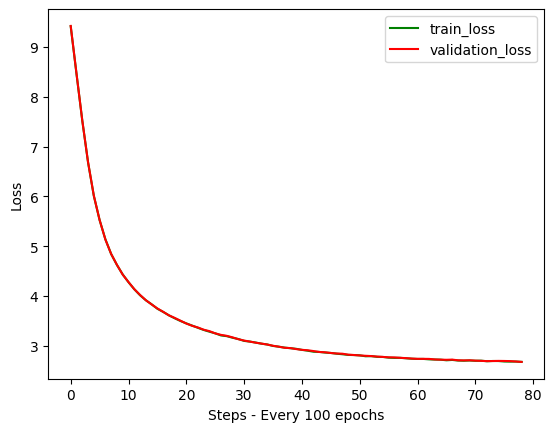

In [ ]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Testing the model

In [15]:
model = GPT(config)
device = "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device)))

<All keys matched successfully>

In [ ]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")
sentence = "A long time ago there is a king and chota Beem in Dolugpur"
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

A long time ago there is a king and chota Beem in Dolugpur T- trophy. They had a pink talent that they made with interesting dreams and restored some tools. Tim was very happy, he went outside with his imagination. He always had a hug she wouldn't even more than she.Once upon a time who were wearing a fair land in life. Herless things, a metal not polite creation. She wanted to know what, but as it was inside the competition. Her grandma said it was just a silly animal.

One day, a little girl namedamus â€œThis factions Live projects is not so helpful!â€™tWhat little one?" Her mother said. 

P together come to the building and searched a fentanyl meadow. Then she reluctantly got the bathling in lucky flowers. She was having a bow, deemsches and lots of fun on stories and soon she was filled with joy. 

Mum said, â€œWhat to I do a each of the kingdom?â


# Download the SLM Model

In [18]:
torch.save(model.state_dict, "slm.pt")

## Calculate Model Parameters
---
Use the Following Code

```python
    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad # Optional
    )

    print(trainable_params)
```

| Module(Plain English Words) | Initianlizations |
|:---|:---|
|Token_embedding_layer(`wte`) | Weights ~ Normal(0, 0.02)|
|Positional Embedding Layer ( `wpe` )|Weights ~ Normal(0, 0.02)|
|Attention Block - LayerNorm before attention|Weight = 1, Bias = 0|
|Attention Block - QKV Linear ( `c_attn` )|Weights ~ Normal(0, 0.02), Bias = 0|
|Attention Block - Output Projection ( `c_proj` )|Weights ~ Normal(0, 0.02 / `sqrt(2 x n_layer)`), Bias = 0|
|Attention Block - LayerNorm before MLP|Weight = 1, Bias = 0|
|MLP Block - First Linear ( `c_fc` )|Weights ~ Normal(0, 0.02), Bias = 0|
|MLP Block - Output Linear ( `c_proj` )|Weights ~ Normal(0, 0.02 / `sqrt(2x n_layer)`), Bias = 0|
|Final LayerNorm ( `In_f` )|Weight = 1, Bias = 0|
|Output Head (`lm_head`)|Tied with token embedding > Weights ~ Normal(0, 0.02)|


```python

GPT class WorkFlow:

Input text  
   ↓  
Tokenizer  
   ↓  
Token IDs  
   ↓  
Token Embedding ─────┐  
                     ├──→ Add → Dropout  
Position Embedding ──┘  
                     ↓  
              Transformer Block 1  
                     ↓  
              Transformer Block 2  
                     ↓  
                    ...  
                     ↓  
              Transformer Block N  
                     ↓  
                 Final LayerNorm  
                     ↓  
                 LM Head  
                     ↓  
               Vocabulary logits  
                     ↓  
               Next-token prediction  
```